In [45]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pretty_midi
from melody import (build_rolls, pad_rolls, compute_highest_per_instrument,
                    track_lead_voice, segment_phrases, find_motifs)

# NAZWA_PLIKU          = 'music/Battlefield_2_Menu_Music.mid'
NAZWA_PLIKU          = 'music/Age_of_Empires_2_Menu_Music.mid'
FS                   = 100
MIN_NOTES            = 10
MIN_PITCH            = 48
MIN_ENERGY_PER_FRAME = 10
SWITCH_N             = 3
MIN_REST_BEATS       = 2
MOTIF_N_RANGE        = (2, 5)  # n-gram lengths to search
TOP_K                = 5       # top motifs to show per length


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
# Standard pipeline from notebook 1
utwor = pretty_midi.PrettyMIDI(NAZWA_PLIKU)
beats = utwor.get_beats()
beat_frames = (beats * FS).astype(int)

rolls, instruments = build_rolls(utwor, fs=FS, min_notes=MIN_NOTES)
padded, max_len = pad_rolls(rolls)
beat_frames_clipped = np.clip(beat_frames, 0, max_len)
n_windows = len(beat_frames_clipped) - 1
n_inst = len(padded)

highest = compute_highest_per_instrument(padded, beat_frames_clipped, MIN_PITCH, MIN_ENERGY_PER_FRAME)
lead_inst_idx, lead_pitch = track_lead_voice(highest, n_windows, n_inst, SWITCH_N)
print(f"{n_windows} beatów, {len(instruments)} instrumentów")

132 beatów, 13 instrumentów


In [47]:
phrases = segment_phrases(lead_pitch, min_rest_beats=MIN_REST_BEATS)

print(f"Znaleziono {len(phrases)} fraz\n")
for i, phrase in enumerate(phrases):
    beats_span = phrase[-1][0] - phrase[0][0] + 1
    pitches = [p for _, p in phrase]
    print(f"Fraza {i+1}: beaty {phrase[0][0]}–{phrase[-1][0]}, "
          f"długość {beats_span} beatów, "
          f"zakres {pretty_midi.note_number_to_name(min(pitches))}–{pretty_midi.note_number_to_name(max(pitches))}")

Znaleziono 4 fraz

Fraza 1: beaty 0–35, długość 36 beatów, zakres A4–A6
Fraza 2: beaty 39–51, długość 13 beatów, zakres G4–A#5
Fraza 3: beaty 55–67, długość 13 beatów, zakres G4–A#5
Fraza 4: beaty 71–131, długość 61 beatów, zakres A3–C6


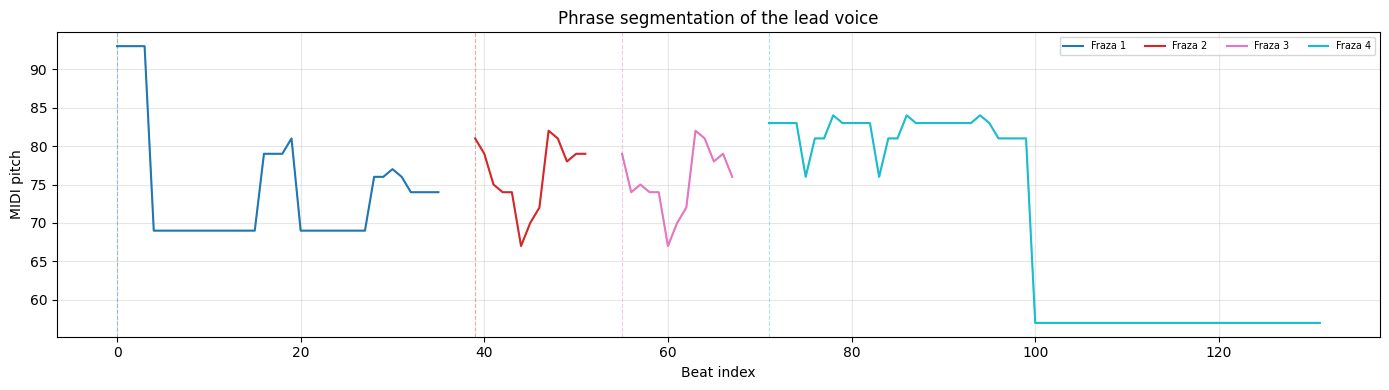

In [48]:
# Visualize phrases on the pitch timeline, each phrase a different colour
fig, ax = plt.subplots(figsize=(14, 4))

colors = plt.cm.tab10(np.linspace(0, 1, max(len(phrases), 1)))

# Background: full lead_pitch in grey
pitch_vals = [p if p is not None else np.nan for p in lead_pitch]
ax.plot(pitch_vals, color='lightgrey', linewidth=1, zorder=1)

# Overlay each phrase in its own colour
for i, phrase in enumerate(phrases):
    beat_indices = [b for b, _ in phrase]
    pitches      = [p for _, p in phrase]
    ax.plot(beat_indices, pitches, color=colors[i], linewidth=1.5,
            label=f'Fraza {i+1}', zorder=2)
    ax.axvline(beat_indices[0], color=colors[i], linestyle='--', alpha=0.4, linewidth=0.8)

ax.set_xlabel('Beat index')
ax.set_ylabel('MIDI pitch')
ax.set_title('Phrase segmentation of the lead voice')
ax.legend(loc='upper right', fontsize=7, ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Średnia długość frazy: 30.8 beatów
Mediana:               24.5 beatów
Min / Max:             13 / 61 beatów


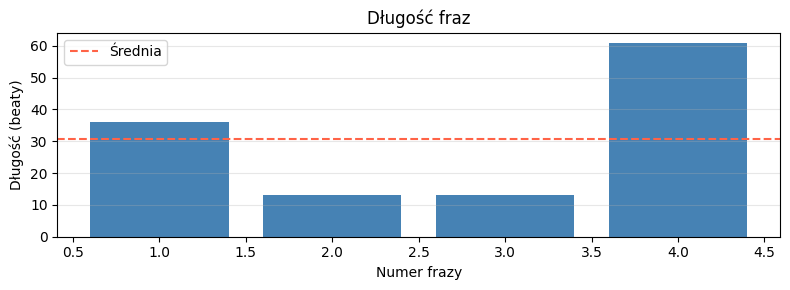

In [49]:
# Phrase length distribution
phrase_lengths = [phrase[-1][0] - phrase[0][0] + 1 for phrase in phrases]

print(f"Średnia długość frazy: {np.mean(phrase_lengths):.1f} beatów")
print(f"Mediana:               {np.median(phrase_lengths):.1f} beatów")
print(f"Min / Max:             {min(phrase_lengths)} / {max(phrase_lengths)} beatów")

plt.figure(figsize=(8, 3))
plt.bar(range(1, len(phrase_lengths) + 1), phrase_lengths, color='steelblue')
plt.axhline(np.mean(phrase_lengths), color='tomato', linestyle='--', label='Średnia')
plt.xlabel('Numer frazy')
plt.ylabel('Długość (beaty)')
plt.title('Długość fraz')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
motifs = find_motifs(phrases, n_range=MOTIF_N_RANGE, top_k=TOP_K)

def fmt_interval(i):
    return f'+{i}' if i > 0 else str(i)

for n, ranked in motifs.items():
    print(f'--- {n}-note motifs (interval n-grams of length {n-1}) ---')
    for ngram, count, positions in ranked:
        intervals_str = ' '.join(fmt_interval(i) for i in ngram)
        print(f'  [{intervals_str}]  x{count}  @ beats {positions}')
    print()


--- 2-note motifs (interval n-grams of length 1) ---
  [+1 -1]  x3  @ beats [28, 56, 87]
  [-1 -7]  x3  @ beats [41, 57, 78]
  [-1 -2]  x2  @ beats [30, 94]
  [-7 +3]  x2  @ beats [42, 58]
  [+3 +2]  x2  @ beats [44, 60]

--- 3-note motifs (interval n-grams of length 2) ---
  [+1 -1 -2]  x2  @ beats [28, 87]
  [-1 -7 +3]  x2  @ beats [41, 57]
  [-7 +3 +2]  x2  @ beats [42, 58]
  [+3 +2 +10]  x2  @ beats [44, 60]
  [+2 +10 -1]  x2  @ beats [45, 61]

--- 4-note motifs (interval n-grams of length 3) ---
  [-1 -7 +3 +2]  x2  @ beats [41, 57]
  [-7 +3 +2 +10]  x2  @ beats [42, 58]
  [+3 +2 +10 -1]  x2  @ beats [44, 60]
  [+2 +10 -1 -3]  x2  @ beats [45, 61]
  [+10 -1 -3 +1]  x2  @ beats [46, 62]

--- 5-note motifs (interval n-grams of length 4) ---
  [-1 -7 +3 +2 +10]  x2  @ beats [41, 57]
  [-7 +3 +2 +10 -1]  x2  @ beats [42, 58]
  [+3 +2 +10 -1 -3]  x2  @ beats [44, 60]
  [+2 +10 -1 -3 +1]  x2  @ beats [45, 61]
  [-24 +10 +2 -12 +7]  x1  @ beats [0]



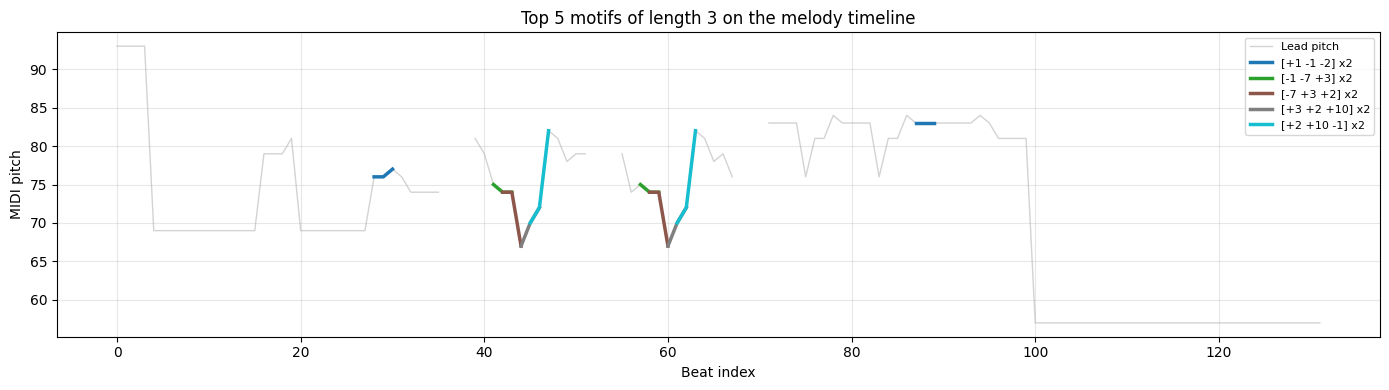

In [57]:
# Show where the top 3 motifs of a chosen n appear on the melody timeline
SHOW_N = 3  # which n-gram length to visualise

pitch_vals = [p if p is not None else float('nan') for p in lead_pitch]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pitch_vals, color='lightgrey', linewidth=1, zorder=1, label='Lead pitch')

colors = plt.cm.tab10(np.linspace(0, 1, TOP_K))
for rank, (ngram, count, positions) in enumerate(motifs[SHOW_N]):
    intervals_str = ' '.join((f'+{i}' if i > 0 else str(i)) for i in ngram)
    label = f'[{intervals_str}] x{count}'
    for beat_start in positions:
        # highlight the SHOW_N notes of the motif
        end = min(beat_start + SHOW_N, len(lead_pitch))
        segment_beats  = list(range(beat_start, end))
        segment_pitches = [pitch_vals[b] for b in segment_beats]
        ax.plot(segment_beats, segment_pitches, color=colors[rank],
                linewidth=2.5, zorder=2,
                label=label if beat_start == positions[0] else '_')

ax.set_xlabel('Beat index')
ax.set_ylabel('MIDI pitch')
ax.set_title(f'Top {TOP_K} motifs of length {SHOW_N} on the melody timeline')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


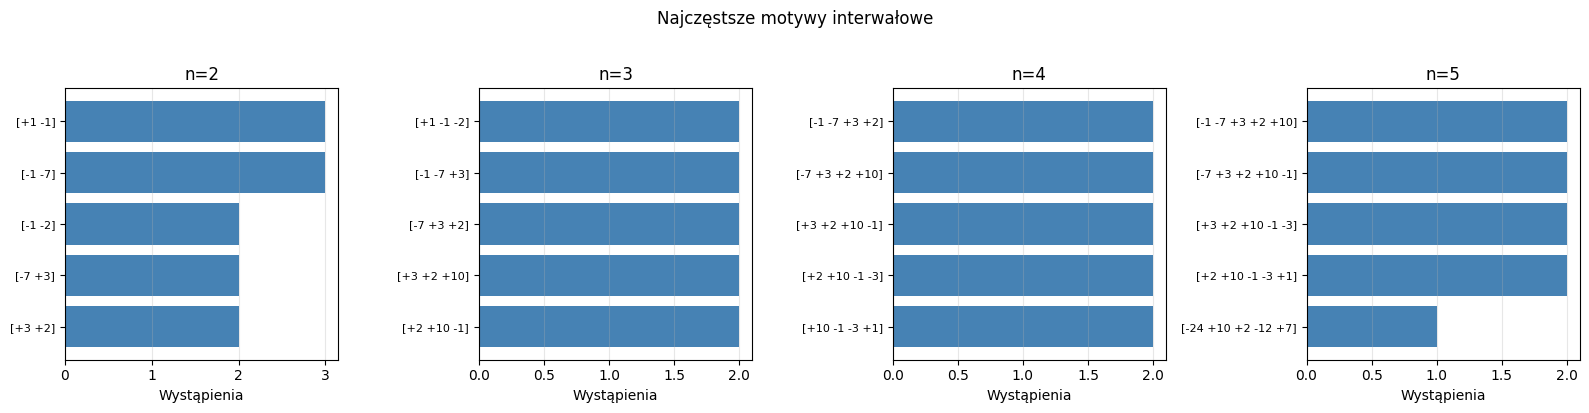

In [52]:
# Frequency bar chart for each n-gram length side by side
fig, axes = plt.subplots(1, len(motifs), figsize=(4 * len(motifs), 4), sharey=False)
if len(motifs) == 1:
    axes = [axes]

for ax, (n, ranked) in zip(axes, motifs.items()):
    labels = ['[' + ' '.join((f'+{i}' if i > 0 else str(i)) for i in ngram) + ']'
              for ngram, _, _ in ranked]
    counts = [count for _, count, _ in ranked]
    ax.barh(range(len(counts)), counts, color='steelblue')
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f'n={n}')
    ax.set_xlabel('Wystąpienia')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Najczęstsze motywy interwałowe', y=1.02)
plt.tight_layout()
plt.show()
